# 1. Setup

Imports, general functions, results loading, and global plotting style.

In [1]:
# imports 

import os, sys
import ast
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import spearmanr
from collections import defaultdict
from glob import glob

In [ ]:
sys.path.insert(0, "..")

# ── Config ────────────────────────────────────────────────────────────────────
CSV_PATH = "../results/summary_20251216/all_results.csv"
OUT_DIR  = "../results/plots"

df = pd.read_csv(CSV_PATH)
df["value_list"] = df["value"].apply(ast.literal_eval)
df["last_layer"] = [values[-1] for values in df["value_list"]]

TASKS = [t for t in df["task"].unique()
                if not (t.endswith("_processed_mean") or t.endswith("_processed_noflatten")) and (t.endswith("_mean") or t.endswith("_noflatten"))]
TASKS = ["proeng_thermo_mixed_split_mean",
         "proeng_aav_low_vs_high_mean",
         "proeng_aav_two_vs_many_mean",
         "proeng_aav_one_vs_many_mean",
         "proeng_gb1_low_vs_high_mean",
         "proeng_gb1_two_vs_rest_mean",
         "proeng_gb1_one_vs_rest_mean",
         "annotation_scl_balanced_mean",
         "structure_secondary_structure_tape_ss3_processed_cb513_noflatten",
         "structure_secondary_structure_tape_ss3_processed_ts115_noflatten",
         "structure_secondary_structure_tape_ss3_processed_casp12_noflatten",
         "evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean",
         "evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean",
         "evolution_remote_homology_tape_rh_processed_test-family-holdout_mean",
        ]
METRIC = "test_performance_2"

MODEL_SIZE = {
    "protxlstm_26M_30B":   26,
    "protxlstm_102M_60B": 102,
    "protmamba_28M_30B":   28,
    "protmamba_107M_195B": 107,
    "poet_201M":           201,
}

PROTXLSTM_CKPT_LOSSES = {
    0.125: 2.3195407390594482,
    0.25: 2.2641046047210693,
    0.375: 2.2123701572418213,
    0.5: 2.158830404281616,
    0.625: 2.119004726409912,
    0.75: 2.033418893814087,
    0.875: 1.9276466369628906,
    1: 1.8841066360473633,
}

ARCH_COLOR = {"protxlstm": "#125e74", "protmamba": "#65a568", "poet": "#f5a931"}

MODEL_LABELS = {
    "protxlstm_26M_30B":   "Prot-xLSTM 26M",
    "protxlstm_102M_60B":  "Prot-xLSTM 102M",
    "protmamba_28M_30B":   "ProtMamba 28M",
    "protmamba_107M_195B": "ProtMamba 107M",
    "poet_201M":           "PoET 201M",
}

MODEL_LINESTYLE = {
    "protxlstm_26M_30B":   "--",
    "protxlstm_102M_60B":  "-",
    "protmamba_28M_30B":   "--",
    "protmamba_107M_195B": "-",
    "poet_201M":           "-",
}

MODEL_MARKERSTYLE = {
    "protxlstm_26M_30B":   ".",
    "protxlstm_102M_60B":  "o",
    "protmamba_28M_30B":   ".",
    "protmamba_107M_195B": "o",
    "poet_201M":           "o",
}


MODEL_SIZE_CAT = {
    "protxlstm_26M_30B":   "S",
    "protxlstm_102M_60B":  "L",
    "protmamba_28M_30B":   "S",
    "protmamba_107M_195B": "L",
    "poet_201M":           "L",
}

ARCH_TO_MODEL = {
    "one-hot": "onehot",
    "protxlstm": "protxlstm_102M_60B",
    "protmamba": "protmamba_107M_195B",
    "poet": "poet_201M",
    "carp": "carp_76M",
    "esm": "esm1_t12_85M_UR50S",
    }


MODEL_LAYERS = {
    "esm1_t6_43M_UR50S": 6,
    "esm1_t12_85M_UR50S": 12,
    "esm1b_t33_650M_UR50S": 33,
    "carp_38M": 16,
    "carp_76M": 32,
    "carp_640M": 56,
    "onehot": 0,
    "protxlstm_26M_30B":   16,
    "protxlstm_102M_60B":  16,
    "protmamba_28M_30B":   16,
    "protmamba_107M_195B": 16,
    "poet_201M":           12,
}

TASK_LABELS = {
    "structure_secondary_structure_tape_ss3_processed_casp12_noflatten": "SS3 - CASP12",
    "structure_secondary_structure_tape_ss3_processed_cb513_noflatten": "SS3 - CB513",
    "structure_secondary_structure_tape_ss3_processed_ts115_noflatten": "SS3 - TS115",
    "evolution_remote_homology_tape_rh_processed_test-family-holdout_mean": "RH - Family",
    "evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean": "RH - Superfamily",
    "evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean": "RH - Fold",
    "annotation_scl_balanced_mean": "SCL",
    "proeng_thermo_mixed_split_mean": "Thermostability",
    "proeng_aav_one_vs_many_mean": "AAV - 1 vs. many",
    "proeng_aav_two_vs_many_mean": "AAV - 2 vs. many",
    "proeng_aav_low_vs_high_mean": "AAV - low vs. high",
    "proeng_gb1_one_vs_rest_mean": "GB1 - 1 vs. rest",
    "proeng_gb1_low_vs_high_mean": "GB1 - low vs. high",
    "proeng_gb1_two_vs_rest_mean": "GB1 - 2 vs. rest",
}

TASK_METRIC_LABELS_2 = {
    "structure_secondary_structure_tape_ss3_processed_casp12_noflatten": "Accuracy",
    "structure_secondary_structure_tape_ss3_processed_cb513_noflatten": "Accuracy",
    "structure_secondary_structure_tape_ss3_processed_ts115_noflatten": "Accuracy",
    "evolution_remote_homology_tape_rh_processed_test-family-holdout_mean": "Top-1 Accuracy",
    "evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean": "Top-1 Accuracy",
    "evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean": "Top-1 Accuracy",
    "annotation_scl_balanced_mean": "Accuracy",
    "proeng_thermo_mixed_split_mean": "Spearman ρ",
    "proeng_aav_one_vs_many_mean": "Spearman ρ",
    "proeng_aav_two_vs_many_mean": "Spearman ρ",
    "proeng_aav_low_vs_high_mean": "Spearman ρ",
    "proeng_gb1_one_vs_rest_mean": "Spearman ρ",
    "proeng_gb1_low_vs_high_mean": "Spearman ρ",
    "proeng_gb1_two_vs_rest_mean": "Spearman ρ",
}

TASK_METRIC_LABELS_1 = {
    "structure_secondary_structure_tape_ss3_processed_casp12_noflatten": "AUC",
    "structure_secondary_structure_tape_ss3_processed_cb513_noflatten": "AUC",
    "structure_secondary_structure_tape_ss3_processed_ts115_noflatten": "AUC",
    "evolution_remote_homology_tape_rh_processed_test-family-holdout_mean": "Top-5 Accuracy",
    "evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean": "Top-5 Accuracy",
    "evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean": "Top-5 Accuracy",
    "annotation_scl_balanced_mean": "AUC",
    "proeng_thermo_mixed_split_mean": "NDCG",
    "proeng_aav_one_vs_many_mean": "NDCG",
    "proeng_aav_two_vs_many_mean": "NDCG",
    "proeng_aav_low_vs_high_mean": "NDCG",
    "proeng_gb1_one_vs_rest_mean": "NDCG",
    "proeng_gb1_low_vs_high_mean": "NDCG",
    "proeng_gb1_two_vs_rest_mean": "NDCG",
}

METRIC_LABELS = {
    "test_performance_1": TASK_METRIC_LABELS_1, 
    "test_performance_2": TASK_METRIC_LABELS_2,
}

TASK_INFO = {"annotation_scl_balanced_mean": ("annotation/scl/balanced", "pytorch", "test"),
         "structure_secondary_structure_tape_ss3_processed_casp12_noflatten": ("structure/secondary_structure/tape_ss3_processed", "pytorch", "casp12"),
         "structure_secondary_structure_tape_ss3_processed_cb513_noflatten": ("structure/secondary_structure/tape_ss3_processed", "pytorch", "cb513"),
         "structure_secondary_structure_tape_ss3_processed_ts115_noflatten": ("structure/secondary_structure/tape_ss3_processed", "pytorch", "ts115"),
         "proeng_gb1_one_vs_rest_mean": ("proeng/gb1/one_vs_rest", "sklearn", "test"),
         "proeng_gb1_low_vs_high_mean": ("proeng/gb1/low_vs_high", "sklearn", "test"),
         "proeng_gb1_two_vs_rest_mean": ("proeng/gb1/two_vs_rest", "sklearn", "test"),
         "proeng_aav_low_vs_high_mean": ("proeng/aav/low_vs_high", "sklearn", "test"),
         "proeng_aav_two_vs_many_mean": ("proeng/aav/two_vs_many", "sklearn", "test"),
         "proeng_aav_one_vs_many_mean": ("proeng/aav/one_vs_many", "sklearn", "test"),
         "proeng_thermo_mixed_split_mean": ("proeng/thermo/mixed_split", "sklearn", "test"),
         "evolution_remote_homology_tape_rh_processed_test-family-holdout_mean": ("evolution/remote_homology/tape_rh_processed", "pytorch", "test_family_holdout"),
         "evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean": ("evolution/remote_homology/tape_rh_processed", "pytorch", "test_superfamily_holdout"),
         "evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean": ("evolution/remote_homology/tape_rh_processed", "pytorch", "test_fold_holdout"),
         }

def _rows(df, model, task, metric, ptp=1.0, seq_num=200, ablation="emb"):
    return df[
        (df["model"]       == model)    &
        (df["ablation"]    == ablation) &
        (df["ptp"]         == ptp)      &
        (df["max_seq_num"] == seq_num)  &
        (df["task"]        == task)     &
        (df["metric"]      == metric)
    ]

def avg_last_layer(sub):
    """Mean ± std across seeds; returns (mean_number, std_number)."""
    arrays = np.array(sub["last_layer"].tolist())
    return arrays.mean(0), arrays.std(0)

def avg_layers(sub):
    """Mean ± std across seeds; returns (mean_array, std_array)."""
    arrays = np.array(sub["value_list"].tolist())
    return arrays.mean(0), arrays.std(0)    

def best_layer(sub, obj="max"):
    """Scalar: max over layers after averaging across seeds."""
    mean, std = avg_layers(sub)
    if obj == "max":
        idx = mean.argmax()
    elif obj == "min":
        idx = mean.argmin()
    return (mean[idx], std[idx]), idx

def get_onehot(task: str, metric):
    subfolder, eval_framework, test_split = TASK_INFO[task]
    ROOT = "../results"
    agg = "noflatten" if "structure" in subfolder else "flatten"
    p = os.path.join(ROOT, f"{eval_framework}-onehot/seed-42", subfolder, "onehot", agg, f"onehot-{agg}-layer_0.pkl")
    df_ = pd.read_pickle(p)

    if eval_framework == "pytorch":
        if metric == "test_performance_1":
            test_metric = "top5_acc" if "evolution" in subfolder else "rocauc"
        else:
            test_metric = "acc"
    else:
        test_metric = "ndcg" if metric == "test_performance_1" else "rho"

    perf = df_[test_split][test_metric]
    return perf if test_metric != "rho" else perf[0]

def perform_t_test(
    grouped_df,
    target_value: float,
    test_col: str = "last_layer",
    sig_cutoff: float = 0.05,
):
    t_statistic, one_tailed_p_value = stats.ttest_1samp(
        grouped_df[test_col], target_value, alternative="less"
    )
    return pd.Series(
        {
            "mean": grouped_df[test_col].mean(),
            "std": grouped_df[test_col].std(),
            "n": len(grouped_df[test_col]),
            "t_statistic": t_statistic,
            "p_value": one_tailed_p_value,
            "significant": one_tailed_p_value < sig_cutoff,
        }
    )

def get_ablation_results(df, model, task, ablation, metric):
    abl_df = _rows(df, model, task, ptp=0.0, seq_num=200, ablation=ablation, metric=metric)
    ref_df = _rows(df, model, task, ptp=1.0, seq_num=200, ablation="emb", metric=metric)

    assert set(ref_df["sampleseed"]) == set(abl_df["sampleseed"]), "Ablation and reference do not have same sampleseeds"
    sampleseeds = ref_df["sampleseed"]

    results = []

    for seed in sampleseeds:
        sub_abl_df = abl_df[abl_df["sampleseed"] == seed]
        sub_ref_df = ref_df[ref_df["sampleseed"] == seed]
        assert len(sub_ref_df) == 1, f"ref_df contains multiple values for {seed}"

        results.append(perform_t_test(
            sub_abl_df,
            sub_ref_df["last_layer"],
            test_col="last_layer",
            sig_cutoff=0.05,
        ))

    return pd.DataFrame(results, index=sampleseeds)

def gradient_line(
    ax,
    x,
    y,
    color="C0",
    alpha_start=0.2,
    alpha_end=1.0,
    linewidth=2,
    linestyle="solid",
    **kwargs,
):
    """
    Draw a line whose alpha increases along the x-direction.

    Parameters
    ----------
    ax : matplotlib axis
    x, y : array-like
        Coordinates of the line.
    color : matplotlib color
        Base color of the line.
    alpha_start : float
        Alpha at the beginning of the line.
    alpha_end : float
        Alpha at the end of the line.
    linewidth : float
        Width of the line.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    # create line segments
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # generate alpha gradient
    alphas = np.linspace(alpha_start, alpha_end, len(segments))

    # convert color to RGBA
    from matplotlib.colors import to_rgba
    r, g, b, _ = to_rgba(color)

    colors = [(r, g, b, a) for a in alphas]

    lc = LineCollection(segments, colors=colors, linewidth=linewidth, linestyle=linestyle, **kwargs)
    ax.add_collection(lc)

    # update limits so matplotlib doesn"t ignore the collection
    ax.autoscale()

    return lc

In [9]:
GLOBAL_STYLE = {
    # Figure
    "figure.figsize": (12, 24),
    "figure.dpi": 75,

    # Fonts
    "font.size": 14,
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Axes
    "axes.linewidth": 1,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,

    # Grid
    "grid.linestyle": "--",
    "grid.alpha": 0.5, # 0.7

    # Ticks
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "ytick.left": False,

    # Error bars
    "errorbar.capsize": 5,

    # Bars / patches
    "patch.edgecolor": "black",
    "patch.linewidth": 1.0,
    "patch.force_edgecolor": False, 

    # Legend
    "legend.fontsize": 12,        
    "legend.title_fontsize": 14,  

    # Savefig
    "savefig.bbox": "tight",

    "hatch.linewidth": 1.5,
}

mpl.rcParams.update(GLOBAL_STYLE)


# 2. Scaling overview by task subset

In [ ]:
# ── Figure ────────────────────────────────────────────────────────────────────
def draw_scaling_plot(tasks, nrows, figsize, outname):
    fig, axs = plt.subplots(nrows, 4, sharey="row", figsize=figsize)
    color_legend = [
        Line2D([0], [0], marker="o", color=ARCH_COLOR["protxlstm"], lw=2, label="Prot-xLSTM"),
        Line2D([0], [0], marker="o", color=ARCH_COLOR["protmamba"], lw=2, label="ProtMamba"),
        Line2D([0], [0], marker="o", color=ARCH_COLOR["poet"], lw=2, label="PoET"),
    ]

    marker_legend = [
        Line2D([0], [0], marker=".", color="black", linestyle="", label="Small"),
        Line2D([0], [0], marker="o", color="black", linestyle="", label="Medium"),
    ]

    for row, task in enumerate(tasks):
        first_row = row == 0
        last_row = row == nrows-1

        if row == nrows:
            break

        # ── (A) Model-size scaling ────────────────────────────────────────────────────
        ax = axs[0] if nrows == 1 else axs[row, 0]
        plotted_archs = set()
        for model, label in MODEL_LABELS.items():
            arch  = model.split("_")[0]
            color = ARCH_COLOR[arch]
            sub   = _rows(df, model, task, metric=METRIC)
            if sub.empty:
                continue
            mean, std = avg_last_layer(sub)
            size = MODEL_SIZE[model]
            marker = MODEL_MARKERSTYLE[model]
            ax.errorbar(size, mean, yerr=std, color=color)
            ax.scatter(size, mean, color=color, s=130, zorder=3, alpha=0.8, 
                    linestyle="None", marker=marker,
                    label=arch if arch not in plotted_archs else "_nolegend_")
            plotted_archs.add(arch)

        if last_row:
            ax.set_xlabel("Parameters (M)")
        ax.set_xlim(0)

        ax.set_ylabel(f"$\\mathbf{{{TASK_LABELS[task]}}}$\n{METRIC_LABELS[METRIC][task]}")

        # ── (B) Layer-wise scaling ────────────────────────────────────────────────────
        ax = axs[1] if nrows == 1 else axs[row, 1]
        for model, label in MODEL_LABELS.items():
            if MODEL_SIZE_CAT[model] == "L":
                color = ARCH_COLOR[model.split("_")[0]]
                ls    = MODEL_LINESTYLE[model]
                sub   = _rows(df, model, task, metric=METRIC)
                if sub.empty:
                    continue
                mean, std = avg_layers(sub)
                x = np.arange(len(mean))
                ax.plot(x, mean, label=label, color=color, linestyle=ls, linewidth=1.8)
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)
        
        if last_row:
            ax.set_xlabel("Layer index")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        # ── (C) Pre-training performance scaling ──────────────────────────────────────
        ax = axs[2]  if nrows == 1 else axs[row, 2]
        model = "protxlstm_102M_60B"
        color = ARCH_COLOR["protxlstm"]
        xs, ys, yerrs = [], [], []
        for ptp, loss in sorted(PROTXLSTM_CKPT_LOSSES.items()):
            sub = _rows(df, model, task, ptp=ptp, metric=METRIC)
            if sub.empty:
                continue
            xs.append(loss)

            mean, std = avg_last_layer(sub)
            ys.append(mean)
            yerrs.append(std)

        gradient_line(ax, xs, ys, color=color, alpha_start=0.1, alpha_end=1.0, linewidth=1.8)
        ax.scatter(xs, ys, marker="o", color=color)#, s=7)

        ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

        ax.invert_xaxis() 

        if last_row:
            ax.set_xlabel("Pretrain loss")

        # ── (D) Context-length scaling ────────────────────────────────────────────────
        ax = axs[3]  if nrows == 1 else axs[row, 3]
        ctx_models  = ["protxlstm_102M_60B", "protmamba_107M_195B", "poet_201M"]
        all_seq_nums = sorted(df["max_seq_num"].unique())

        for model in ctx_models:
            arch  = model.split("_")[0]
            color = ARCH_COLOR[arch]
            label = MODEL_LABELS[model]

            xs, ys, yerrs = [], [], []
            for seq_num in all_seq_nums:
                sub = _rows(df, model, task, seq_num=seq_num, metric=METRIC)
                if sub.empty:
                    continue
                xs.append(seq_num)

                mean, std = avg_last_layer(sub)
                ys.append(mean)
                yerrs.append(std)
            if len(xs) > 1:
                ax.plot(xs, ys, "o-", color=color, label=label, linewidth=1.8, markersize=7)
                ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

        ax.set_xticks(all_seq_nums)
        if last_row:
            ax.set_xlabel("Max. context sequences")
        if row+1 == nrows // 2:
            ax.legend(handles=marker_legend, title="Model Size", title_fontproperties={"weight": "bold","size": 12}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))
        if row == nrows // 2:
            ax.legend(handles=color_legend, title="Architecture", title_fontproperties={"weight": "bold","size": 12}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))

        ymin, ymax = ax.get_ylim()

        min_range = 0.1
        current_range = ymax - ymin

        if current_range < min_range:
            center = (ymin + ymax) / 2
            ax.set_ylim(center - min_range/2, center + min_range/2)

    fig.tight_layout()
    for ext in [".svg", ".png"]:
        fig.savefig(os.path.join(OUT_DIR, f"scaling_{outname}-{METRIC}{ext}"),
                    bbox_inches="tight", dpi=150)

    plt.show()

## Subset 1 — Thermostability & SS3 (CB513, TS115, CASP12)

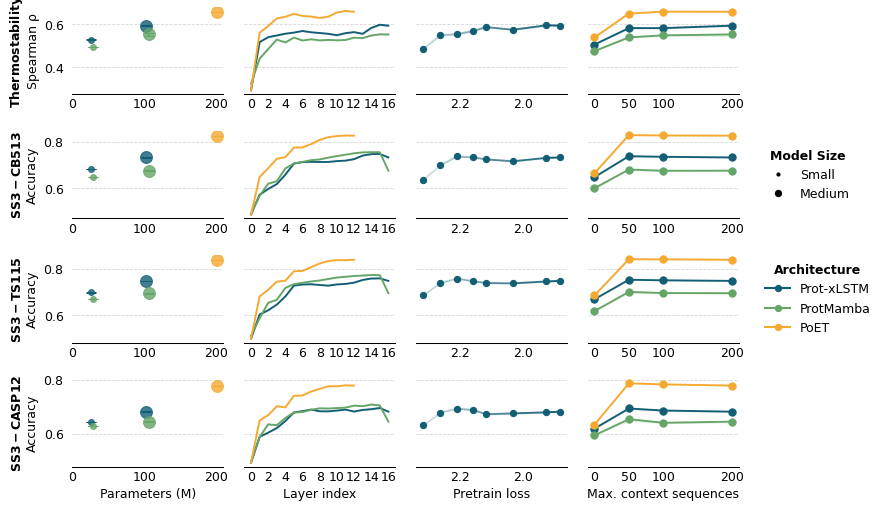

In [25]:
task_subset = [
    "proeng_thermo_mixed_split_mean",
    "structure_secondary_structure_tape_ss3_processed_cb513_noflatten",
    "structure_secondary_structure_tape_ss3_processed_ts115_noflatten",
    "structure_secondary_structure_tape_ss3_processed_casp12_noflatten",
]

draw_scaling_plot(nrows=4, tasks=task_subset, figsize=(12,7), outname="nearalignment")

## Subset 2 — SCL, AAV (1-vs, 2-vs, low), GB1 (1-vs, low)

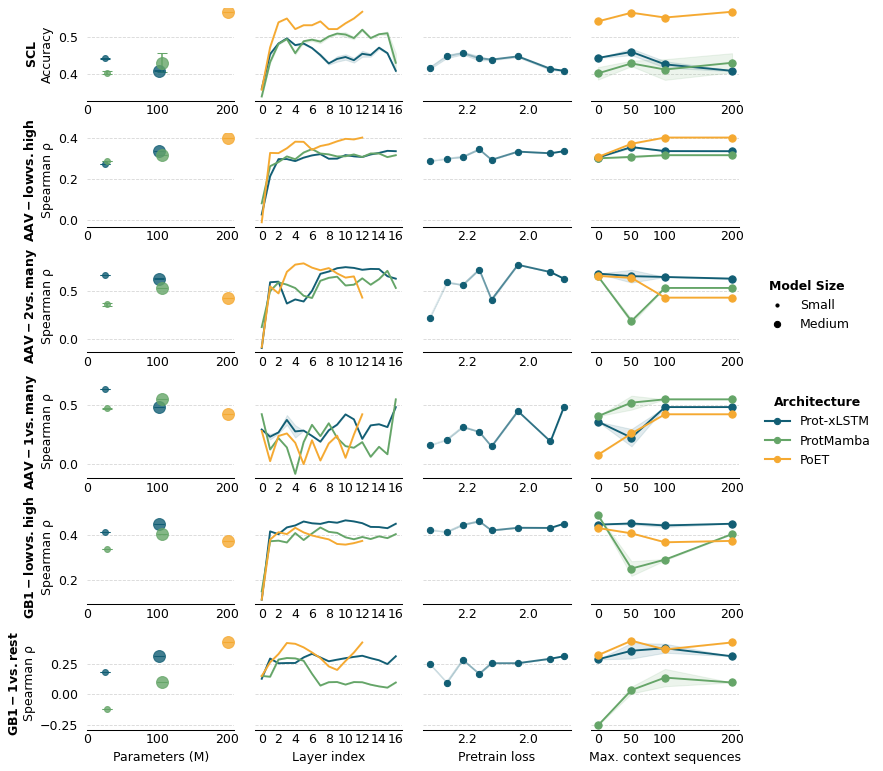

In [24]:
task_subset = [
    "annotation_scl_balanced_mean",
    "proeng_aav_low_vs_high_mean",
    "proeng_aav_two_vs_many_mean",
    "proeng_aav_one_vs_many_mean",
    "proeng_gb1_low_vs_high_mean",
    "proeng_gb1_one_vs_rest_mean",
]

draw_scaling_plot(nrows=6, tasks=task_subset, figsize=(12,10.5), outname="lowlevel")

## Subset 3 — Remainder: GB1 (2-vs-rest) & Remote Homology

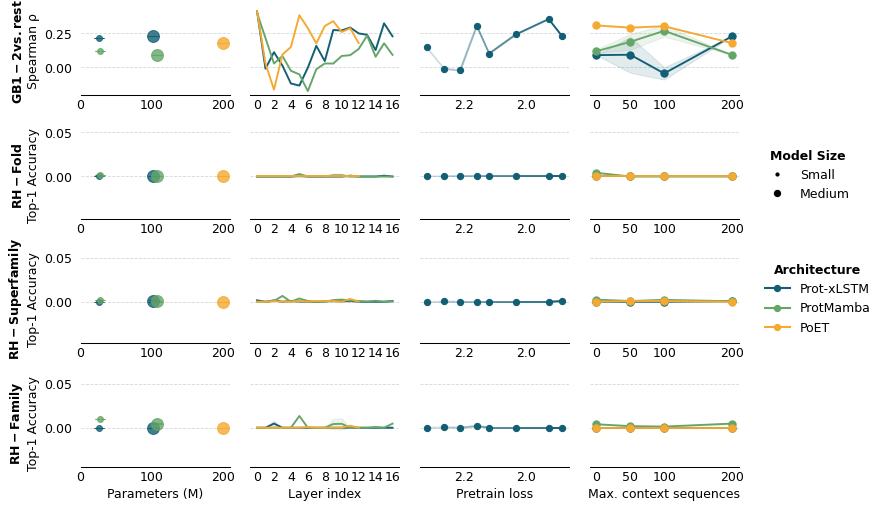

In [ ]:
task_subset = [
    "proeng_gb1_two_vs_rest_mean",
    "evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean",
    "evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean",
    "evolution_remote_homology_tape_rh_processed_test-family-holdout_mean"
    ]

draw_scaling_plot(task_subset, nrows, (12,7), outname="noalignment")

# 3. Ablations

Vertical, multi-color butterfly chart (Δ performance vs. one-hot baseline).

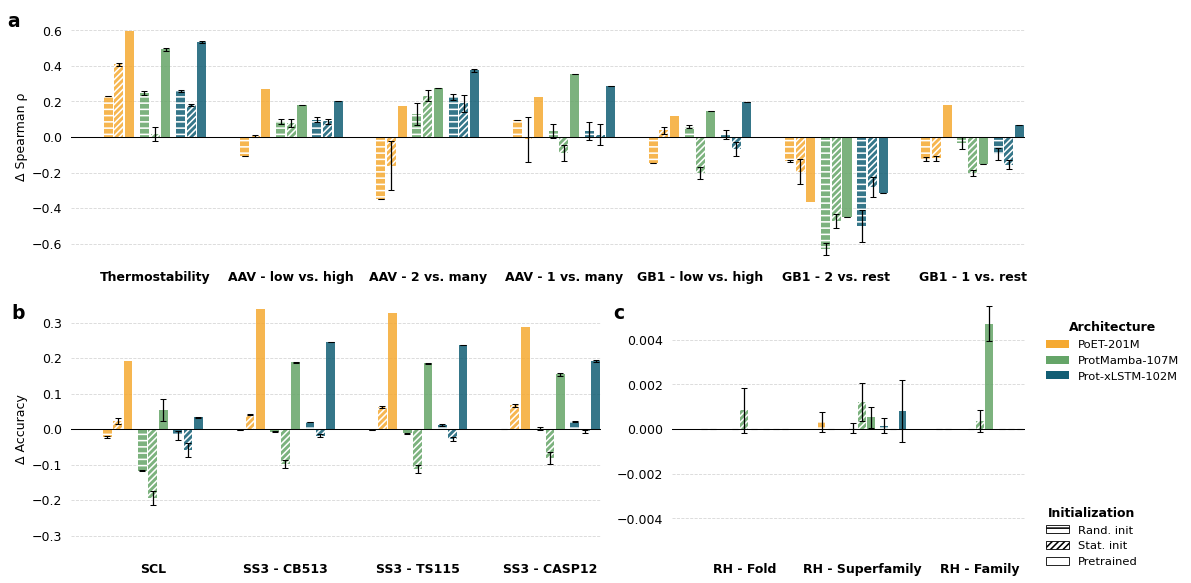

In [ ]:

MODELS = {
    "protxlstm": "protxlstm_102M_60B",
    "protmamba": "protmamba_107M_195B",
    "poet":      "poet_201M",
}
ARCH_LABEL = {
    "protxlstm": "Prot-xLSTM-102M",
    "protmamba": "ProtMamba-107M",
    "poet":      "PoET-201M",
}
HATCHES = {
    "pretrained": "",
    "stat":       "////",
    "rand":       "--",
}
COND_LABELS = {
    "pretrained": "Pretrained",
    "stat":       "Stat. init",
    "rand":       "Rand. init",
}

ARCHS      = list(MODELS.keys())[::-1]
CONDITIONS = ["pretrained", "stat", "rand"][::-1]

plt.rcParams.update({"hatch.color": "white", "ytick.right": False, "xtick.major.size": 0,})

# ── Task groups ────────────────────────────────────────────────────────────────
spearman_tasks  = [t for t in TASKS if t.startswith("proeng")]
structure_tasks = [t for t in TASKS if t.startswith("structure") or t.startswith("annotation")]
evolution_tasks = [t for t in TASKS if t.startswith("evolution")]

# ── Data retrieval ─────────────────────────────────────────────────────────────
def fetch_data(tasks):
    """Returns onehot_vals (n_tasks,) and data[arch][cond] = (means, stds)."""
    # oh_tasks = [t.replace("mean", "flatten") if t.endswith("mean") else t for t in tasks]
    oh_vals  = np.array([get_onehot(t, metric=METRIC) for t in tasks])

    d = {}
    for arch, model in MODELS.items():
        d[arch] = {}
        for cond in CONDITIONS:
            vals = []
            for t in tasks:
                sub = (_rows(df, model, t, metric=METRIC) if cond == "pretrained"
                       else _rows(df, model, t, ptp=0.0, ablation=cond, metric=METRIC))
                vals.append((sub["last_layer"].mean(), sub["last_layer"].std())
                            if not sub.empty else (np.nan, np.nan))
            d[arch][cond] = (np.array([v[0] for v in vals]),
                             np.array([v[1] for v in vals]))
    return oh_vals, d


# ── Drawing helper ─────────────────────────────────────────────────────────────
def draw_butterfly(ax, tasks, oh_vals, data,
                   bar_h=0.10, arch_pad=0.04, task_pad=0.30,
                   show_xlabel=True):
    n_tasks  = len(tasks)
    group_h   = len(CONDITIONS) * bar_h
    cluster_h = len(ARCHS) * group_h + (len(ARCHS) - 1) * arch_pad

    ypos       = {}
    task_ytick = []
    y_cur = 0
    for t in range(n_tasks):
        for a, arch in enumerate(ARCHS):
            group_bot = y_cur + a * (group_h + arch_pad)
            for c, cond in enumerate(CONDITIONS):
                ypos[(t, arch, cond)] = group_bot + c * bar_h + bar_h / 2
        task_ytick.append(y_cur + cluster_h / 2)
        y_cur += cluster_h + task_pad

    for t, task in enumerate(tasks):
        onehot = oh_vals[t]
        for arch in ARCHS:
            color = ARCH_COLOR[arch]
            for cond in CONDITIONS:
                means, stds = data[arch][cond]
                delta = means[t] - onehot
                err   = stds[t]
                y     = ypos[(t, arch, cond)]
                ax.bar(
                    y, delta,
                    width=bar_h * 0.85,
                    color=color,
                    hatch=HATCHES[cond],
                    # edgecolor="black",
                    linewidth=0.5,
                    alpha=0.85,
                    yerr=None if np.isnan(err) else err,
                    error_kw={"capsize": 3, "elinewidth": 1.2, "capthick": 1},
                )

    ax.axhline(0, color="black", linewidth=1, zorder=5)

    ax.set_xticks(task_ytick)
    ax.set_xticklabels([TASK_LABELS[t] for t in tasks], fontsize=12, fontweight="bold")
    ax.tick_params(
               bottom=False,
               labelbottom=True)
    
    ax.set_xlim(-task_pad, y_cur - task_pad)
    

    if show_xlabel:
        labels = TASK_METRIC_LABELS_2 if METRIC == "test_performance_2" else TASK_METRIC_LABELS_1
        ax.set_ylabel(f"Δ {labels[task]}", fontsize=12)


    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(False)
    ax.grid(axis="y")

    ymin, ymax = ax.get_ylim()
    bound = max(abs(ymin), abs(ymax))
    ax.set_ylim(-bound, bound)


# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[3, 2])

ax_big    = fig.add_subplot(gs[0, :])
ax_small1 = fig.add_subplot(gs[1, 0])
ax_small2 = fig.add_subplot(gs[1, 1])

oh_spearman,  d_spearman  = fetch_data(spearman_tasks)
oh_structure, d_structure = fetch_data(structure_tasks)
oh_evolution, d_evolution = fetch_data(evolution_tasks)

draw_butterfly(ax_big,    spearman_tasks,  oh_spearman,  d_spearman,  show_xlabel=True)
draw_butterfly(ax_small1, structure_tasks, oh_structure, d_structure, show_xlabel=True)
draw_butterfly(ax_small2, evolution_tasks, oh_evolution, d_evolution, show_xlabel=False)

ax_big.set_title("a", fontweight="bold", x=-0.06, y=0.9, fontsize=18)
ax_small1.set_title("b", fontweight="bold", x=-0.1, y=0.9, fontsize=18)
ax_small2.set_title("c", fontweight="bold", x=-0.15, y=0.9, fontsize=18)

# ── Shared legend ──────────────────────────────────────────────────────────────
arch_patches = [
    mpatches.Patch(facecolor=ARCH_COLOR[a],  linewidth=0.8, label=ARCH_LABEL[a])
    for a in ARCHS
]
cond_patches = [
    mpatches.Patch(facecolor="white", hatch=HATCHES[c], edgecolor="black", linewidth=0.8, label=COND_LABELS[c])
    for c in CONDITIONS
]

leg1 = ax_small2.legend(handles=cond_patches,  title_fontproperties={"weight": "bold", "size": 12}, title="Initialization", loc="center left", frameon=False, fontsize=11, bbox_to_anchor=(1.03,0.085)) # -0.3
ax_small2.add_artist(leg1)

ax_small2.legend(handles=arch_patches, title_fontproperties={"weight": "bold", "size": 12}, title="Architecture",  loc="center left", frameon=False, fontsize=11, bbox_to_anchor=(1.03,0.8))

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"butterfly_chart-{METRIC}{ext}"), bbox_inches="tight", dpi=150)
plt.show()
